# L-Systems

A self-contained refresher on **Lindenmayer systems (L-systems)** — a parallel string-rewriting
grammar that grows a short *axiom* into a long string by applying replacement **rules** over and
over, then **interprets** that string as turtle-graphics commands to draw plants, fractals, and
branching structures.

**Domain:** Procedural Generation  ·  **runnable:** yes

## 1. What & Why

**An L-system is a tiny grammar that you apply to *every* symbol at once, then read the result as
drawing instructions.** Aristid Lindenmayer (a biologist) invented them in 1968 to model how
plants grow: each cell divides according to the same local rule, simultaneously, generation after
generation. That "all symbols rewrite in parallel" step is the whole trick — it produces the
**self-similar, recursively branching** look of ferns, trees, and snowflake fractals with a
handful of characters.

**Reach for an L-system when** you want organic-looking, recursive, *branching* geometry from a
compact deterministic (or lightly randomized) specification: vegetation, coral, river networks,
blood vessels, road skeletons, space-filling curves, and classic fractals (Koch, Sierpinski,
dragon curve). The spec is so small it makes a great seed/parameter — a 3-line grammar is a
level's worth of trees.

**Don't reach for one when** the structure isn't recursive/branching: terrain heightmaps (use
noise or diamond-square), room-and-corridor dungeons (BSP / cellular automata), or constraint-
driven tilemaps (Wave Function Collapse). L-systems give you a *skeleton/path*, not a filled grid.

## 2. Mental Model

**Think "find-and-replace, applied to every character at the same time, run N times — then hand
the result to a turtle."**

Two completely separate phases:

1. **Rewrite (the grammar).** Start with the **axiom** (e.g. `"A"`). Each generation, replace
   *every* symbol using the rules **simultaneously** (a symbol with no rule stays itself).
   `A → AB`, `B → A` turns `A` into `AB` into `ABA` into `ABAAB`… The string explodes
   exponentially; nothing is drawn yet.
2. **Interpret (the turtle).** Walk the final string left to right driving a pen: `F` = draw
   forward, `+`/`-` = turn right/left, and the magic pair `[` / `]` = **push / pop** the turtle's
   position+heading onto a stack. `[` starts a branch; `]` snaps back to where the branch began.
   That stack is exactly what makes a tree look like a tree.

The key difference from an ordinary grammar (Chomsky / context-free): in a CFG you rewrite **one**
nonterminal per step; in an L-system you rewrite **all** symbols **in parallel** every step. That
parallelism is why one rule produces growth at every scale at once.

## 3. Key Concepts

- **Axiom (start string).** The initial seed the rewriting begins from, e.g. `"F"`.
- **Production rules.** `predecessor → successor` maps. Applied to *every* matching symbol each
  generation, in parallel. Symbols with no rule are **constants** and pass through unchanged.
- **Generation / depth.** How many times you apply the rules. String length (and detail) grows
  roughly exponentially, so depth 6–8 is usually plenty.
- **Turtle alphabet.** A convention for interpreting the string:
  `F`/`G` draw forward, `f` move forward without drawing, `+`/`-` turn by a fixed **angle**,
  `[` push state, `]` pop state. Other letters (`A`, `X`, `Y`) are usually *control symbols* that
  drive rewriting but draw nothing.
- **Bracketed L-system.** One that uses `[ ]` — this is what gives **branching** (plants, trees).
- **Deterministic vs stochastic (D0L vs stochastic).** Deterministic = one rule per symbol
  (same output every time). **Stochastic** = a symbol has several successors chosen by
  probability, giving natural variation between plants.
- **Context-sensitive / parametric.** Advanced variants where a rule fires only given neighbours
  (context) or where symbols carry numeric parameters (e.g. `F(2.0)` for length) — used for
  realistic botany. We focus on the common deterministic + stochastic bracketed case.

## 4. Setup

The rewriting engine is **pure Python stdlib** — no install needed. We only use `matplotlib` to
*draw* the turtle path (and `random` for the stochastic example). If you just want the strings,
you need nothing at all.

In [1]:
# matplotlib is the only third-party dep, and only for plotting the turtle path.
# Uncomment if it's missing in your environment:
# %pip install matplotlib
import math
import random

import matplotlib
import matplotlib.pyplot as plt

print("matplotlib", matplotlib.__version__)

matplotlib 3.11.0


## 5. Worked Examples

We build the whole thing from two small functions and reuse them across every example:

- `expand(axiom, rules, depth)` — the **parallel rewrite** (the grammar).
- `turtle(commands, angle, ...)` — the **interpreter** that turns a string into `(x, y)` line
  segments using a push/pop stack.

Then: (1) the **Koch curve** (no branching, shows pure rewriting), (2) a **bracketed plant**
(shows the stack), and (3) a **stochastic plant** (shows variation).

In [2]:
def expand(axiom: str, rules: dict, depth: int) -> str:
    """Apply production rules to EVERY symbol in parallel, `depth` times.

    `rules` maps a single character -> its replacement string. A character with
    no rule is a constant and passes through unchanged. This parallel rewrite is
    what separates an L-system from an ordinary context-free grammar.
    """
    s = axiom
    for _ in range(depth):
        s = "".join(rules.get(ch, ch) for ch in s)
    return s


# Cantor-style sanity check: A->AB, B->A (the classic Lindenmayer algae example).
for d in range(5):
    out = expand("A", {"A": "AB", "B": "A"}, d)
    print(f"gen {d}: len={len(out):>3}  {out}")

gen 0: len=  1  A
gen 1: len=  2  AB
gen 2: len=  3  ABA
gen 3: len=  5  ABAAB
gen 4: len=  8  ABAABABA


Those lengths are the Fibonacci sequence (1, 2, 3, 5, 8…) — a famous property of this exact
grammar, and a quick proof that `expand` rewrites in parallel correctly. Now the interpreter.

In [3]:
def turtle(commands: str, angle: float, step: float = 1.0, start_heading: float = 90.0):
    """Interpret an L-system string as turtle graphics; return a list of line segments.

    Alphabet:  F/G draw forward · f move without drawing · +/- turn by `angle` (deg)
               [ push (x, y, heading) · ] pop it back  -> this stack makes branches.
    Letters with no turtle meaning (A, X, Y, ...) are skipped while drawing.
    """
    x, y, heading = 0.0, 0.0, start_heading
    stack, segments = [], []
    for ch in commands:
        if ch in "FG":
            nx = x + step * math.cos(math.radians(heading))
            ny = y + step * math.sin(math.radians(heading))
            segments.append(((x, y), (nx, ny)))
            x, y = nx, ny
        elif ch == "f":
            x += step * math.cos(math.radians(heading))
            y += step * math.sin(math.radians(heading))
        elif ch == "+":
            heading -= angle
        elif ch == "-":
            heading += angle
        elif ch == "[":
            stack.append((x, y, heading))
        elif ch == "]":
            x, y, heading = stack.pop()
    return segments


def draw(segments, title, ax):
    """Plot turtle segments on a matplotlib axis with equal aspect."""
    for (x0, y0), (x1, y1) in segments:
        ax.plot([x0, x1], [y0, y1], color="forestgreen", linewidth=0.7)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{title}  ({len(segments)} segments)", fontsize=9)


print("turtle() and draw() defined")

turtle() and draw() defined


### Example 1 — Koch curve (rewriting, no branching)

Axiom `F`, single rule `F → F+F--F+F`, 60° turns. Each `F` is replaced by a bump, recursively, so
every straight segment becomes a smaller version of the whole curve — the essence of a fractal.

depth 0: string length = 1
depth 1: string length = 8
depth 2: string length = 36
depth 3: string length = 148


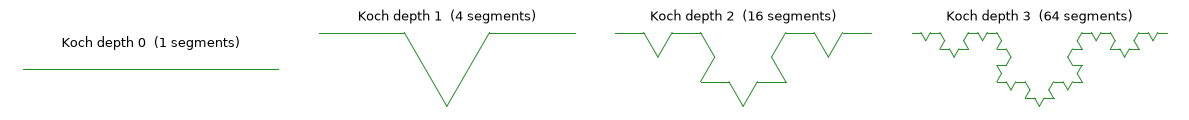

In [4]:
koch_rules = {"F": "F+F--F+F"}
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for depth, ax in enumerate(axes):
    s = expand("F", koch_rules, depth)
    draw(turtle(s, angle=60, start_heading=0), f"Koch depth {depth}", ax)
    print(f"depth {depth}: string length = {len(s)}")
fig.tight_layout()
plt.show()

### Example 2 — Bracketed plant (the `[ ]` stack is everything)

This is Prusinkiewicz's classic plant from *The Algorithmic Beauty of Plants* (figure 1.24, plant
**f**). Axiom `X`; `X` is a *control symbol* that draws nothing but spawns branches, while `F`
rewrites to grow the trunk. Watch how `[` / `]` let the turtle dart out along a branch and snap
back to the fork.

depth 3: string length =   379, segments = 84
depth 4: string length =  1551, segments = 360


depth 5: string length =  6263, segments = 1488


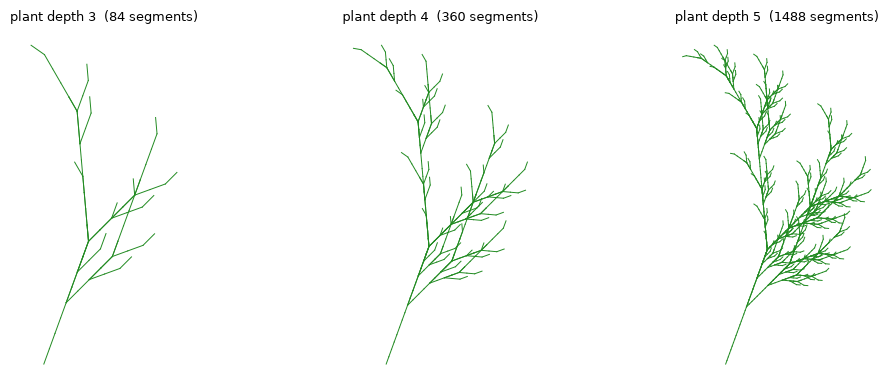

In [5]:
plant_rules = {
    "X": "F+[[X]-X]-F[-FX]+X",
    "F": "FF",
}
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for depth, ax in zip((3, 4, 5), axes):
    s = expand("X", plant_rules, depth)
    segs = turtle(s, angle=25, start_heading=70)
    draw(segs, f"plant depth {depth}", ax)
    print(f"depth {depth}: string length = {len(s):>5}, segments = {len(segs)}")
fig.tight_layout()
plt.show()

### Example 3 — Stochastic plant (variation from probabilistic rules)

A deterministic L-system always draws the *same* plant. Real forests vary, so we give `X` several
possible successors and pick one per occurrence by weighted random choice. Same grammar, seeded
RNG → reproducible but visibly different plants. This is how you populate a scene with a "species"
rather than clones.

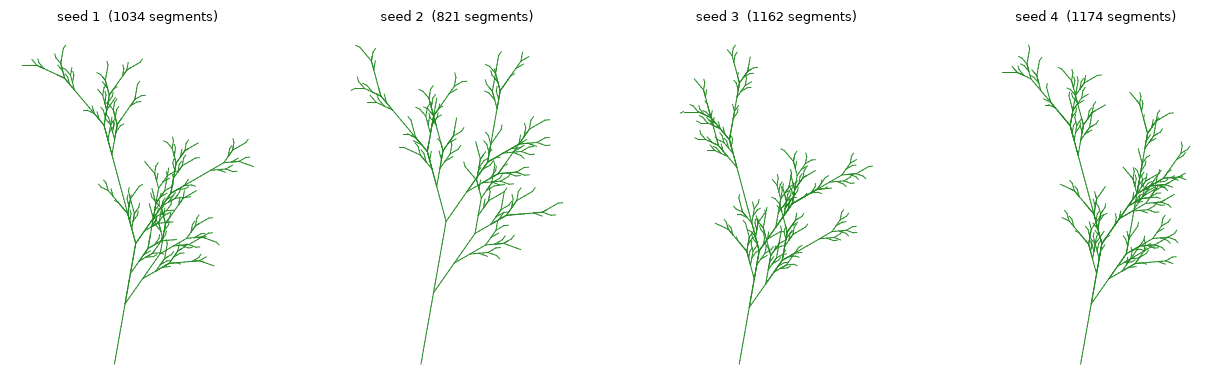

4 distinct plants from one grammar


In [6]:
def expand_stochastic(axiom: str, rules: dict, depth: int, rng: random.Random) -> str:
    """Like expand(), but a rule value may be a list of (weight, successor) options."""
    s = axiom
    for _ in range(depth):
        out = []
        for ch in s:
            rule = rules.get(ch, ch)
            if isinstance(rule, list):
                weights, choices = zip(*[(w, c) for w, c in rule])
                rule = rng.choices(choices, weights=weights, k=1)[0]
            out.append(rule)
        s = "".join(out)
    return s


stoch_rules = {
    "X": [
        (0.34, "F+[[X]-X]-F[-FX]+X"),
        (0.33, "F-[[X]+X]+F[+FX]-X"),
        (0.33, "F[+X]F[-X]+X"),
    ],
    "F": "FF",
}
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for seed, ax in zip((1, 2, 3, 4), axes):
    s = expand_stochastic("X", stoch_rules, depth=5, rng=random.Random(seed))
    draw(turtle(s, angle=25, start_heading=80), f"seed {seed}", ax)
fig.tight_layout()
plt.show()
print("4 distinct plants from one grammar")

## 6. Gotchas & Pitfalls

- **Exponential blow-up.** String length grows like (rule-expansion-factor)^depth. A rule that
  roughly triples per generation hits millions of characters by depth ~13. Always print/cap the
  length and keep depth small (6–8 is usually enough detail). Build the string with `"".join(...)`,
  never repeated `+=` on a `str`.
- **Forgetting the stack = no branches.** If you drop `[`/`]`, every "branch" just keeps drawing
  from wherever the last one ended and you get a tangled scribble, not a tree. Branching *is* the
  push/pop stack.
- **Unbalanced brackets.** A stray `]` pops an empty stack (crash); a missing `]` leaves the
  turtle stranded out on a limb. Validate that `[` and `]` counts match before interpreting.
- **Control symbols vs draw symbols.** `X` (and `A`, `Y`) typically draw *nothing* — they only
  steer rewriting. Beginners give `X` a forward-draw meaning and get doubled or wrong geometry.
  Decide your alphabet up front: which letters draw, which only rewrite.
- **Angle and start heading matter a lot.** The same grammar at 20° vs 90° looks like a totally
  different organism. Heading convention (0° = east, 90° = up here) is yours to fix — be
  consistent or your plant grows sideways.
- **Greedy/overlapping predecessors.** Classic L-systems rewrite *single symbols*. If you want
  multi-character or context-sensitive matches, you must scan carefully (longest-match, look at
  neighbours) — a naive `str.replace` chained per rule will re-rewrite output from an earlier rule
  in the *same* generation, which breaks the parallel semantics. (Our `expand` avoids this by
  mapping each original char exactly once.)
- **Stochastic ≠ reproducible by default.** Seed your RNG (`random.Random(seed)`) if you want the
  same plant from the same seed — essential for saving a scene as just its parameters.

## 7. When to Use vs Alternatives

| Approach | Best at | Why pick over L-systems | Why L-systems win |
|---|---|---|---|
| **L-systems** | recursive, self-similar **branching** structures (plants, fractals, vessels, river/road skeletons) | — | tiny deterministic spec; growth at every scale from one rule |
| **Perlin/Simplex/Worley noise** | continuous terrain, textures, clouds | smooth fields, cheap, tileable | noise has no branching or hierarchy |
| **Cellular automata** | caves, blob/organic *regions*, smoothing | emergent area-fill from local rules | CA fills space; it doesn't make explicit tree paths |
| **Wave Function Collapse** | tilemaps that match an example's local adjacency | learns constraints from a sample, no hand-written grammar | WFC is a grid solver, not a recursive path generator |
| **Diamond-square / fBm** | fractal heightmaps | direct elevation grids | not branching geometry |
| **Context-free grammars (Tracery)** | text / discrete content, one-symbol-per-step expansion | sequential rewriting, great for words/phrases | CFGs rewrite one nonterminal at a time, no parallel growth or turtle |
| **Hand-authored / mesh modelling** | exact art-directed assets | full artistic control | far more labour; no procedural variation |

**Rules of thumb.** Branching + self-similar + want a *compact seed* → L-system. Need it to grow
from an example image/tileset → WFC. Need a smooth field or heightmap → noise / diamond-square.
Need organic *regions* rather than paths → cellular automata. L-systems also compose: generate a
river/road **skeleton** with an L-system, then fill the surrounding terrain with noise.

See also: [`cellular-automata`](cellular-automata.ipynb),
[`wave-function-collapse`](wave-function-collapse.ipynb),
[`perlin-noise`](perlin-noise.ipynb), [`context-free-grammars`](context-free-grammars.ipynb),
[`tracery`](tracery.ipynb).

## 8. Resources

- **The Algorithmic Beauty of Plants** — Prusinkiewicz & Lindenmayer, the canonical reference,
  free PDF: <http://algorithmicbotany.org/papers/abop/abop.pdf>
- **Wikipedia: L-system** — solid overview with the standard examples and turtle alphabet:
  <https://en.wikipedia.org/wiki/L-system>
- **Paul Bourke — L-System User Notes** — a compendium of ready-to-use grammars (Koch, dragon,
  Sierpinski, plants) with angles: <http://paulbourke.net/fractals/lsys/>
- **The Coding Train — Fractal Trees / L-systems** — approachable video walkthrough of building
  the rewrite + turtle from scratch: <https://www.youtube.com/watch?v=E1B4UoSQMFw>
- **Houdini / Blender L-system tools** — if you want production 3D plants, both ship L-system
  generators (SideFX *L-System SOP*, Blender *Sapling*/add-ons) built on these same ideas.